In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [3]:
df = sns.load_dataset('iris')
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [4]:
y = df['species']
x = df.drop('species', axis=1)

In [5]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

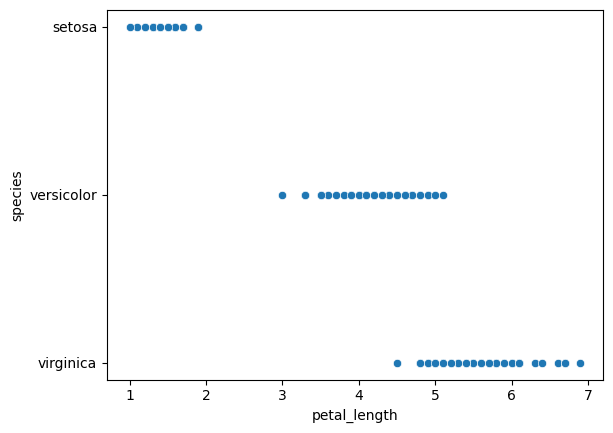

In [6]:
sns.scatterplot(x='petal_length',y='species',data=df)
plt.show()

<Axes: >

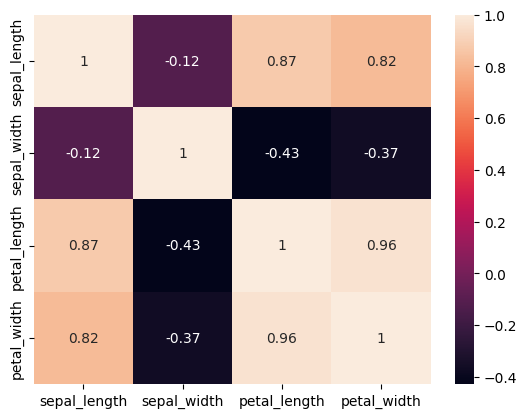

In [7]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [8]:
features = ['sepal_length','sepal_width','petal_length','petal_width']
x = df[features]
y = df['species']

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [10]:
preprocessor = ColumnTransformer([('num', StandardScaler(), features)])
pipeline = Pipeline([ ('preprocessor', preprocessor),('model', LogisticRegression())])
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 1.0


In [11]:
import pickle
pickle.dump(pipeline,open('tips_model.pkl', 'wb'))